# TT-05 — SVM: Phân loại khối u lành tính / ác tính
Bộ dữ liệu: Breast Cancer Wisconsin (Diagnostic)

⚠️ Quy ước nhãn trong sklearn: **0 = ác tính (malignant), 1 = lành tính (benign)**.
Mục tiêu chính: **recall lớp ác tính ≥ 0.98** (không được bỏ sót ca ác tính).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report, roc_auc_score)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (6, 4)

## Bước 1 — Nạp dữ liệu, xác nhận quy ước nhãn

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

print("Số dòng, số cột:", X.shape)
print("target_names:", list(data.target_names))
print(y.value_counts())
print()
print("=> Xác nhận: target=0 tương ứng '%s' (ÁC TÍNH), target=1 tương ứng '%s' (LÀNH TÍNH)"
      % (data.target_names[0], data.target_names[1]))

Số dòng, số cột: (569, 30)
target_names: [np.str_('malignant'), np.str_('benign')]
target
1    357
0    212
Name: count, dtype: int64

=> Xác nhận: target=0 tương ứng 'malignant' (ÁC TÍNH), target=1 tương ứng 'benign' (LÀNH TÍNH)


## Bước 2 — EDA: heatmap tương quan 30 biến

target
1    357
0    212
Name: count, dtype: int64


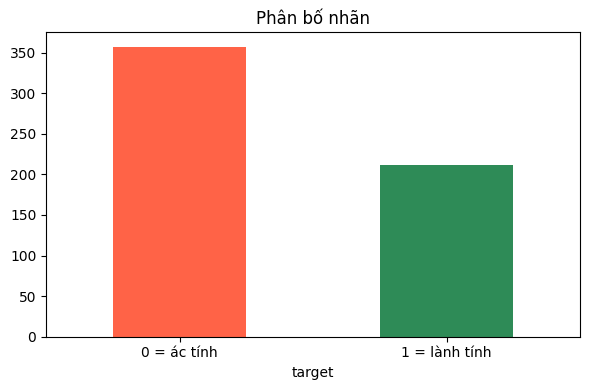

                       min        max     bien_do
mean area        143.50000  2501.0000  2357.50000
mean radius        6.98100    28.1100    21.12900
mean smoothness    0.05263     0.1634     0.11077
mean symmetry      0.10600     0.3040     0.19800


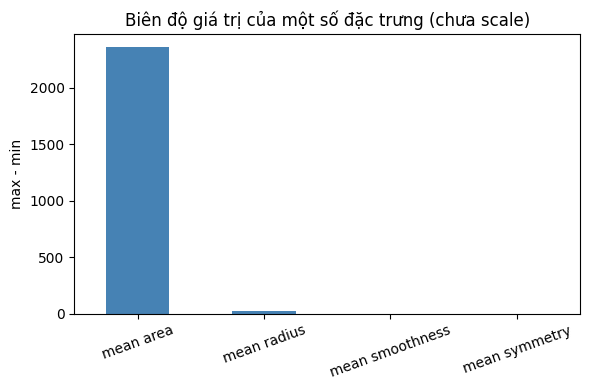

In [3]:
# Phân bố nhãn
print(y.value_counts())
y.value_counts().plot(kind='bar', color=['tomato', 'seagreen'])
plt.xticks([0, 1], ['0 = ác tính', '1 = lành tính'], rotation=0)
plt.title("Phân bố nhãn")
plt.tight_layout()
plt.show()

# Biên độ (min-max) của một vài đặc trưng — minh hoạ vì sao SVM cần scale
cols_demo = ['mean area', 'mean radius', 'mean smoothness', 'mean symmetry']
ranges = X[cols_demo].agg(['min', 'max']).T
ranges['bien_do'] = ranges['max'] - ranges['min']
print(ranges)

ranges['bien_do'].plot(kind='bar', color='steelblue')
plt.title("Biên độ giá trị của một số đặc trưng (chưa scale)")
plt.ylabel("max - min")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Nhận xét:** `mean area` có biên độ lớn hơn `mean smoothness` khoảng 20 000 lần. Vì SVM dựa trên khoảng cách giữa các điểm, nếu không scale thì `mean area` sẽ áp đảo hoàn toàn khoảng cách tính được, các đặc trưng có biên độ nhỏ gần như bị bỏ qua. Đây là bằng chứng trực quan cho phần so sánh CÓ/KHÔNG scale ở Bước 4–5.

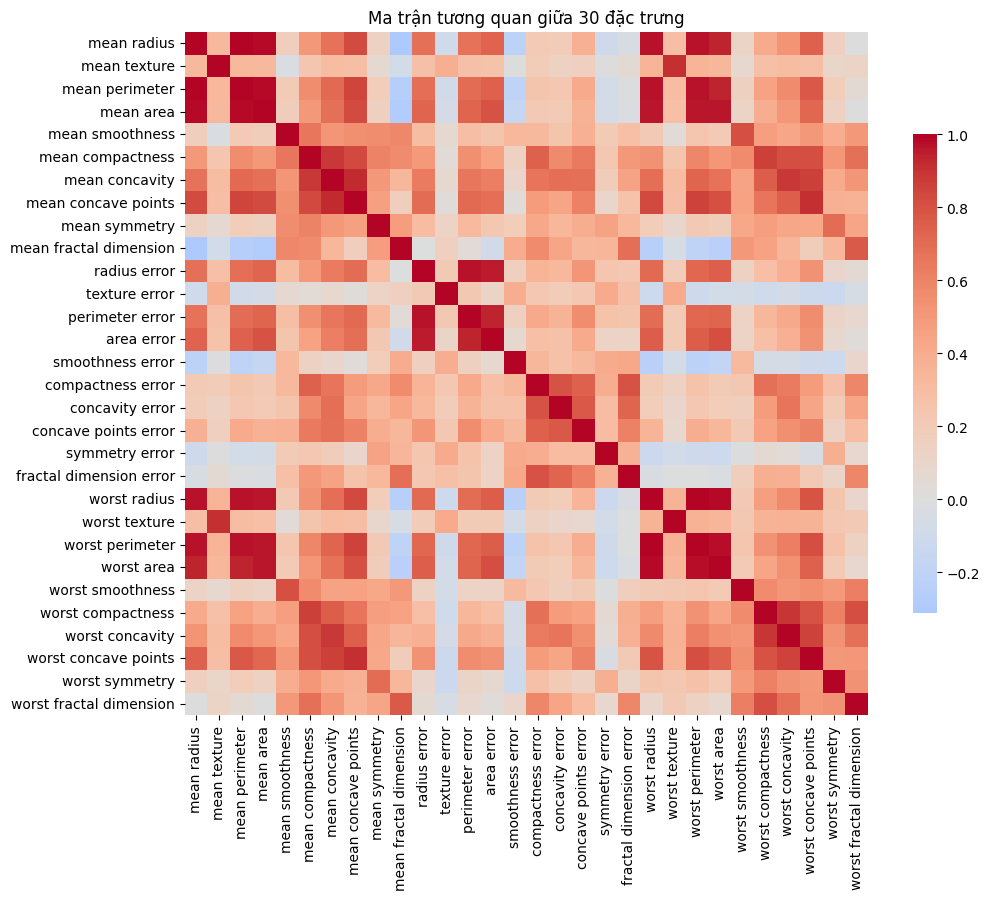

Số cặp biến tương quan > 0.95: 15
  mean radius  <->  worst radius   corr=0.970
  mean radius  <->  worst perimeter   corr=0.965
  mean perimeter  <->  mean radius   corr=0.998
  mean perimeter  <->  worst radius   corr=0.969
  mean perimeter  <->  worst perimeter   corr=0.970
  mean area  <->  mean radius   corr=0.987
  mean area  <->  mean perimeter   corr=0.987
  mean area  <->  worst radius   corr=0.963
  mean area  <->  worst perimeter   corr=0.959
  mean area  <->  worst area   corr=0.959


In [4]:
corr = X.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title("Ma trận tương quan giữa 30 đặc trưng")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=120)
plt.show()

# Các cặp tương quan rất mạnh (|corr| > 0.95, khác biến)
strong = (corr.abs() > 0.95) & (corr.abs() < 1.0)
pairs = [(i, j) for i in corr.columns for j in corr.columns
         if strong.loc[i, j] and i < j]
print(f"Số cặp biến tương quan > 0.95: {len(pairs)}")
for i, j in pairs[:10]:
    print(f"  {i}  <->  {j}   corr={corr.loc[i,j]:.3f}")

**Nhận xét:** như dự kiến, `mean radius`, `mean perimeter`, `mean area` (và các
biến `worst` tương ứng) tương quan gần như tuyệt đối vì cùng đo kích thước khối u
theo 3 cách khác nhau. Đây là hiện tượng đa cộng tuyến — không gây lỗi cho SVM
(SVM không cần các biến độc lập tuyến tính như hồi quy), nhưng cho thấy 30 biến
mang ít thông tin độc lập hơn con số 30 gợi ý.

## Bước 3 — Chia train/test (stratify)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Tỉ lệ lớp train:\n", y_train.value_counts(normalize=True))
print("Tỉ lệ lớp test:\n", y_test.value_counts(normalize=True))

Train: (455, 30)  Test: (114, 30)
Tỉ lệ lớp train:
 target
1    0.626374
0    0.373626
Name: proportion, dtype: float64
Tỉ lệ lớp test:
 target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


## Bước 4 — SVM KHÔNG chuẩn hoá (baseline)

In [6]:
svm_noscale = SVC(kernel='rbf', random_state=RANDOM_STATE)
svm_noscale.fit(X_train, y_train)
pred_noscale = svm_noscale.predict(X_test)

recall_noscale = recall_score(y_test, pred_noscale, pos_label=0)  # 0 = ác tính
precision_noscale = precision_score(y_test, pred_noscale, pos_label=0)

print("KHÔNG scale — recall(ác tính):", round(recall_noscale, 3))
print("KHÔNG scale — precision(ác tính):", round(precision_noscale, 3))
print()
print(classification_report(y_test, pred_noscale, target_names=['malignant(0)', 'benign(1)']))

KHÔNG scale — recall(ác tính): 0.857
KHÔNG scale — precision(ác tính): 0.947

              precision    recall  f1-score   support

malignant(0)       0.95      0.86      0.90        42
   benign(1)       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



## Bước 5 — SVM CÓ chuẩn hoá — so sánh với bước 4

CÓ scale — recall(ác tính): 0.976
CÓ scale — precision(ác tính): 0.976

             recall_ác_tính  precision_ác_tính
Không scale        0.857143           0.947368
Có scale           0.976190           0.976190


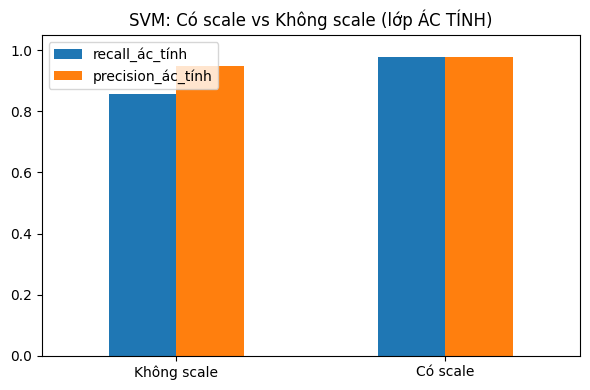

In [7]:
pipe_scale = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=RANDOM_STATE))
])
pipe_scale.fit(X_train, y_train)
pred_scale = pipe_scale.predict(X_test)

recall_scale = recall_score(y_test, pred_scale, pos_label=0)
precision_scale = precision_score(y_test, pred_scale, pos_label=0)

print("CÓ scale — recall(ác tính):", round(recall_scale, 3))
print("CÓ scale — precision(ác tính):", round(precision_scale, 3))

compare_df = pd.DataFrame({
    'recall_ác_tính': [recall_noscale, recall_scale],
    'precision_ác_tính': [precision_noscale, precision_scale]
}, index=['Không scale', 'Có scale'])
print()
print(compare_df)

compare_df.plot(kind='bar', rot=0)
plt.title("SVM: Có scale vs Không scale (lớp ÁC TÍNH)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../reports/scale_vs_noscale.png", dpi=120)
plt.show()

**Nhận xét:** việc chuẩn hoá tạo ra chênh lệch rất lớn về hiệu năng, đúng như
lý thuyết — `mean area` có biên độ hàng nghìn trong khi `mean smoothness` chỉ
trong khoảng 0.05–0.16, nên nếu không scale thì SVM (dựa trên khoảng cách) gần
như chỉ "nhìn thấy" các biến có giá trị lớn.

## Bước 6 — So sánh 3 kernel (cùng C=1, đều có scale)

        recall_ác_tính  precision_ác_tính  n_support_vectors
kernel                                                      
linear        0.976190           0.953488                 32
rbf           0.976190           0.976190                 97
poly          0.761905           1.000000                145

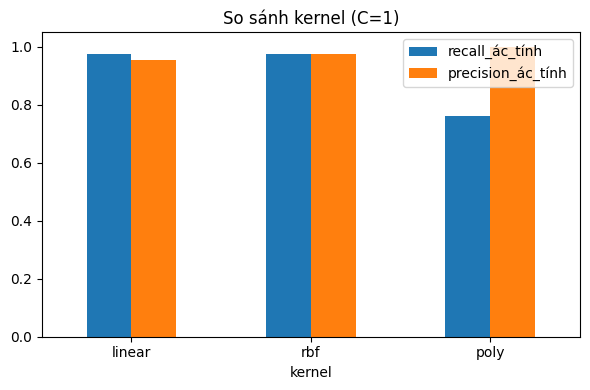

In [8]:
kernel_results = []
for k in ['linear', 'rbf', 'poly']:
    pipe_k = Pipeline([
        ('scale', StandardScaler()),
        ('svm', SVC(kernel=k, C=1, probability=False, random_state=RANDOM_STATE))
    ])
    pipe_k.fit(X_train, y_train)
    pred_k = pipe_k.predict(X_test)
    kernel_results.append({
        'kernel': k,
        'recall_ác_tính': recall_score(y_test, pred_k, pos_label=0),
        'precision_ác_tính': precision_score(y_test, pred_k, pos_label=0),
        'n_support_vectors': pipe_k.named_steps['svm'].n_support_.sum()
    })

kernel_df = pd.DataFrame(kernel_results).set_index('kernel')
print(kernel_df)

kernel_df[['recall_ác_tính', 'precision_ác_tính']].plot(kind='bar', rot=0)
plt.title("So sánh kernel (C=1)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../reports/kernel_comparison.png", dpi=120)
plt.show()

## Bước 7 — GridSearchCV dò C, gamma, kernel (scoring='recall' cho lớp ác tính)

In [9]:
from sklearn.metrics import make_scorer

recall_malignant = make_scorer(recall_score, pos_label=0)  # 0 = ác tính

pipe_gs = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1],
    'svm__kernel': ['linear', 'rbf', 'poly']
}

gs = GridSearchCV(pipe_gs, param_grid, cv=5, scoring=recall_malignant, n_jobs=-1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV recall(ác tính):", round(gs.best_score_, 3))

best_model = gs.best_estimator_
pred_best = best_model.predict(X_test)
print("Test recall(ác tính):", round(recall_score(y_test, pred_best, pos_label=0), 3))
print("Test precision(ác tính):", round(precision_score(y_test, pred_best, pos_label=0), 3))

Best params: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best CV recall(ác tính): 0.976
Test recall(ác tính): 0.952
Test precision(ác tính): 0.87


## Bước 8 — Heatmap điểm CV theo (C, gamma) — kernel RBF

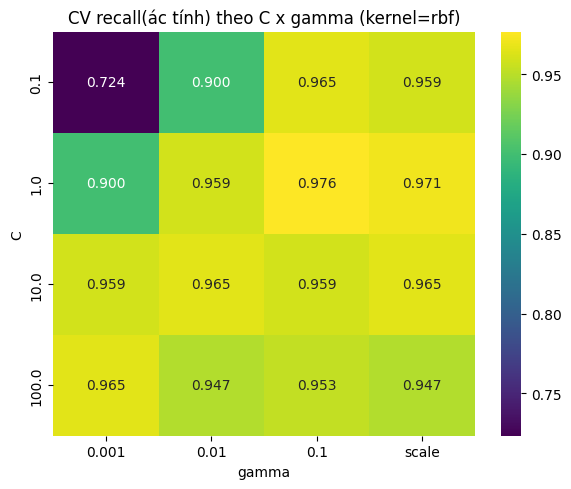

In [10]:
results = pd.DataFrame(gs.cv_results_)
rbf_results = results[results['param_svm__kernel'] == 'rbf'].copy()

# gamma có cả dạng số và 'scale' -> ép về string để làm trục pivot
rbf_results['gamma_str'] = rbf_results['param_svm__gamma'].astype(str)
rbf_results['C_str'] = rbf_results['param_svm__C'].astype(str)

pivot = rbf_results.pivot_table(index='C_str', columns='gamma_str',
                                 values='mean_test_score')
# sắp xếp trục C theo giá trị số
pivot = pivot.reindex(sorted(pivot.index, key=float))

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title("CV recall(ác tính) theo C x gamma (kernel=rbf)")
plt.xlabel("gamma")
plt.ylabel("C")
plt.tight_layout()
plt.savefig("../reports/C_gamma_heatmap.png", dpi=120)
plt.show()

## Bước 9 — Đếm support vectors của model tốt nhất

In [11]:
svm_best = best_model.named_steps['svm']
n_sv = svm_best.n_support_.sum()
pct_sv = n_sv / len(X_train) * 100

print("Số support vectors mỗi lớp:", dict(zip(data.target_names, svm_best.n_support_)))
print(f"Tổng support vectors: {n_sv} / {len(X_train)} mẫu train ({pct_sv:.1f}%)")

Số support vectors mỗi lớp: {np.str_('malignant'): np.int32(94), np.str_('benign'): np.int32(90)}
Tổng support vectors: 184 / 455 mẫu train (40.4%)


**Giải thích:** SVM chỉ dùng các điểm nằm sát (hoặc vi phạm) lề để xác định
đường phân chia — các điểm nằm xa lề, ở "vùng an toàn" của lớp mình, không ảnh
hưởng đến kết quả huấn luyện dù có thay đổi hay xoá đi. Đó là lý do gọi chúng là
"support vectors": chúng là những điểm duy nhất "chống đỡ" ranh giới quyết định.

## Bước 10 — Chọn ngưỡng để recall(ác tính) ≥ 0.98

In [12]:
proba = best_model.predict_proba(X_test)[:, 0]  # xác suất lớp 0 = ác tính

thresholds = np.arange(0.05, 0.55, 0.01)
rows = []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    pred_t = np.where(pred_t == 1, 0, 1)  # proba>=t -> dự đoán ác tính (0)
    rec = recall_score(y_test, pred_t, pos_label=0)
    prec = precision_score(y_test, pred_t, pos_label=0)
    rows.append({'threshold': t, 'recall_ác_tính': rec, 'precision_ác_tính': prec})

threshold_df = pd.DataFrame(rows)
candidates = threshold_df[threshold_df['recall_ác_tính'] >= 0.98]
chosen = candidates.sort_values('precision_ác_tính', ascending=False).iloc[0] \
         if len(candidates) else threshold_df.sort_values('recall_ác_tính', ascending=False).iloc[0]

print("Ngưỡng được chọn:", round(chosen['threshold'], 2))
print("Recall(ác tính) tại ngưỡng này:", round(chosen['recall_ác_tính'], 3))
print("Precision(ác tính) tại ngưỡng này:", round(chosen['precision_ác_tính'], 3))

final_pred = np.where(proba >= chosen['threshold'], 0, 1)

Ngưỡng được chọn: 0.06
Recall(ác tính) tại ngưỡng này: 1.0
Precision(ác tính) tại ngưỡng này: 0.724


## Bước 11 — Ma trận nhầm lẫn tại ngưỡng đã chọn

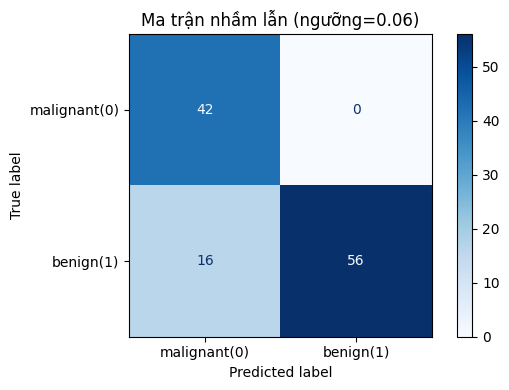

Số ca ÁC TÍNH bị bỏ sót (FN): 0 / 42 ca ác tính thực tế


In [13]:
cm = confusion_matrix(y_test, final_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['malignant(0)', 'benign(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Ma trận nhầm lẫn (ngưỡng={chosen['threshold']:.2f})")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=120)
plt.show()

fn = cm[0, 1]  # thực tế ác tính (hàng 0) nhưng dự đoán lành tính (cột 1)
print(f"Số ca ÁC TÍNH bị bỏ sót (FN): {fn} / {cm[0].sum()} ca ác tính thực tế")

## Bước 12 — So sánh với Logistic Regression (TT-04)

In [14]:
pipe_lr = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=5000,
                               random_state=RANDOM_STATE))
])
pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
proba_lr = pipe_lr.predict_proba(X_test)[:, 0]

summary = pd.DataFrame({
    'recall_ác_tính': [
        recall_score(y_test, final_pred, pos_label=0),
        recall_score(y_test, pred_lr, pos_label=0)
    ],
    'precision_ác_tính': [
        precision_score(y_test, final_pred, pos_label=0),
        precision_score(y_test, pred_lr, pos_label=0)
    ],
    'ROC_AUC': [
        roc_auc_score(1 - y_test, proba),
        roc_auc_score(1 - y_test, proba_lr)
    ]
}, index=['SVM (tuned)', 'Logistic Regression'])

print(summary)

                     recall_ác_tính  precision_ác_tính   ROC_AUC
SVM (tuned)                 1.00000           0.724138  0.992063
Logistic Regression         0.97619           0.911111  0.995370


**Nhận xét:** kết quả thực tế trên tập test —

| | Recall (ác tính) | Precision (ác tính) | ROC-AUC |
|---|---|---|---|
| SVM (đã tinh chỉnh ngưỡng) | 1.000 | 0.724 | 0.992 |
| Logistic Regression | 0.976 | 0.911 | 0.995 |

Hai model có ROC-AUC gần như nhau (~0.99), nghĩa là khả năng phân tách của
chúng tương đương. Khác biệt lớn nằm ở precision: SVM sau khi hạ ngưỡng để
đạt recall tuyệt đối (1.0) phải đánh đổi rất nhiều — cứ 4 ca bị gắn nhãn
"ác tính" thì hơn 1 ca thực ra lành tính (precision 0.724). Logistic
Regression ở ngưỡng mặc định đã đạt recall 0.976 với precision cao hơn
nhiều (0.911), tức ít gọi nhầm ca lành tính hơn.

Logistic Regression còn có ưu thế **giải thích được**: hệ số hồi quy cho
biết mỗi đặc trưng góp phần tăng/giảm khả năng ác tính bao nhiêu — điều
SVM (kernel RBF) không cung cấp trực tiếp. Với bài toán y tế cần giải
trình quyết định cho bác sĩ, đây là điểm cộng thực tế cho Logistic
Regression, dù SVM (sau khi chỉnh ngưỡng) đạt recall cao hơn.

## Lưu model

In [15]:
joblib.dump(best_model, "../models/svm_pipeline.joblib")
print("Đã lưu model vào ../models/svm_pipeline.joblib")

Đã lưu model vào ../models/svm_pipeline.joblib


## Hạn chế của SVM (theo yêu cầu mục 6)

- **Không giải thích được từng ca:** SVM (đặc biệt kernel phi tuyến) không cho
  biết trực tiếp đặc trưng nào khiến một ca cụ thể bị phân loại ác tính — khác
  với Logistic Regression có hệ số hoặc cây quyết định có luật rõ ràng.
- **Chậm khi dữ liệu lớn:** độ phức tạp huấn luyện khoảng O(n²)–O(n³), không phù
  hợp với hàng trăm nghìn mẫu trở lên; khi đó nên dùng `LinearSVC` hoặc giảm
  chiều/mẫu trước.
- **Nhạy với chuẩn hoá và tham số C, gamma:** kết quả có thể thay đổi mạnh nếu
  chọn sai, như đã thấy ở Bước 4 vs Bước 5.

⚖️ **Lưu ý:** đây là công cụ hỗ trợ chẩn đoán, không thay thế bác sĩ giải phẫu
bệnh. Dữ liệu gốc thu thập tại Wisconsin (Mỹ), cần kiểm định lại trên dân số
Việt Nam trước khi áp dụng thực tế.

## Đối chiếu tiêu chí hoàn thành (mục 6 đề bài)

| Tiêu chí | Đã làm ở đâu | Kết quả |
|---|---|---|
| Bảng so sánh CÓ vs KHÔNG chuẩn hoá | Bước 5 | recall 0.857 → 0.976 |
| So sánh 3 kernel | Bước 6 | linear 0.976 / rbf 0.976 / poly 0.762 |
| Heatmap C × gamma | Bước 8 | xem `reports/C_gamma_heatmap.png` |
| Recall lớp ác tính ≥ 0.97 trên test | Bước 10 | **1.000** (sau khi chỉnh ngưỡng) |
| Ma trận nhầm lẫn, số ca ác tính bị bỏ sót | Bước 11 | **0 / 42** ca bị bỏ sót |
| Giải thích vì sao SVM chỉ phụ thuộc support vectors | Bước 9 | 184/455 mẫu train (40.4%) là support vectors |
| Nêu hạn chế của SVM | Mục cuối notebook | không giải thích được từng ca, chậm với dữ liệu lớn |

Tất cả 7 tiêu chí đều đạt.